préparation de l'environnement

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import du dataset

In [66]:
df = pd.read_csv("../data/smart_building_raw.csv")
df

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui


# Partie 1 Exploration des données

1) **Afficher les premières lignes du dataset**

In [67]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


3) **Afficher les dernières lignes du dataset**

In [68]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


4) **Combien d'observations contient le dataset** ?

In [69]:
nombre_de_lignes = len(df)
print(nombre_de_lignes)

507


5) **Combien de variables possède le dataset** ?

In [70]:
nombre_variables = df.shape[1]
print(nombre_variables)

14


6) **Identifier les variables numériques**

In [71]:
variables_numeriques = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(variables_numeriques)

['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


7) Identifier les variables catégorielles

In [72]:
variables_categorielles = df.select_dtypes(include=['object']).columns.tolist()
print(variables_categorielles)

['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


C:\Users\DELL\AppData\Local\Temp\ipykernel_22460\169641225.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categorielles = df.select_dtypes(include=['object']).columns.tolist()


8) Identifier les dates

In [73]:
variable_date = 'date'
print(df[variable_date].head())

0    2025-02-13 06:00:00
1    2025-03-10 12:00:00
2    2025-05-04 00:00:00
3    2025-01-19 00:00:00
4    2025-04-24 06:00:00
Name: date, dtype: str


9) Identifier les identifiants

In [74]:
variable_identifiant = 'id_mesure'
print(df[variable_identifiant].head())

0    1174
1    1275
2    1493
3    1073
4    1454
Name: id_mesure, dtype: int64


10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles

In [75]:
df.describe()

,id_mesure,temperature,humidite,co2,occupation,consommation_kwh
count,507.000000,495.000000,496.000000,500.000000,501.000000,502.000000
mean,1251.114398,24.154141,57.864113,844.150000,44.850299,169.069323
std,144.782769,7.418465,16.026336,582.181386,24.949139,53.164294
min,1001.000000,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,1125.500000,21.600000,49.275000,623.750000,27.000000,136.875000
50%,1252.000000,24.000000,57.550000,787.500000,46.000000,169.800000
75%,1376.500000,26.000000,65.750000,952.000000,61.000000,202.975000
max,1500.000000,96.000000,160.000000,6000.000000,116.000000,336.200000


11) Y a-t-il des variables potentiellement problématiques ?

In [76]:
print(df.dtypes)
print(df.isnull().sum())

id_mesure               int64
date                      str
batiment                  str
type_batiment             str
zone                      str
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation        str
etat_systeme              str
jour_semaine              str
alerte                    str
dtype: object
id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64


12) Pour les données incohérentes :

a) rechercher des valeurs telles que humidité < 0 ;

In [77]:
df[df['humidite'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
281,1126,2025-02-01 06:00:00,B2,École,D,24.8,-5.0,759.0,57.0,225.2,Boost,Normal,Samedi,Non
335,1036,2025-01-09 18:00:00,B4,Bureau,D,21.2,-8.0,160.0,25.0,120.2,Normal,Alerte,Jeudi,Non
366,1216,2025-02-23 18:00:00,B3,Hôpital,B,23.2,-12.0,702.0,41.0,119.8,Normal,Normal,Dimanche,Non


b) rechercher des valeurs telles que humidité > 100

In [78]:
df[df['humidite'] > 100]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
103,1016,2025-01-04 18:00:00,B6,Université,B,26.9,145.0,670.0,28.0,175.9,Normal,Normal,Samedi,Non
128,1156,2025-02-08 18:00:00,B1,Bureau,A,NaN,160.0,941.0,37.0,149.8,Eco,Normal,Samedi,Oui
160,1186,2025-02-16 06:00:00,B8,Entrepôt,B,24.9,125.0,NaN,18.0,123.5,Normal,Normal,Dimanche,Non
268,1276,2025-03-10 18:00:00,B1,Bureau,D,26.0,140.0,633.0,25.0,148.3,Normal,Normal,Lundi,Non
327,1066,2025-01-17 06:00:00,B2,École,C,25.8,132.0,646.0,14.0,93.6,Eco,Normal,Vendredi,Non
342,1096,2025-01-24 18:00:00,B8,Entrepôt,A,20.3,110.0,783.0,55.0,121.0,Normal,Normal,Vendredi,Non


c) rechercher des valeurs telles que température extrêmement élevée

In [79]:
df[(df['temperature'] > 45) | (df['temperature'] < -10)]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
7,1141,2025-02-05 00:00:00,B2,École,D,72.5,78.3,257.0,100.0,239.7,Boost,Alerte,Mercredi,Non
116,1181,2025-02-15 00:00:00,B6,Université,A,96.0,86.5,874.0,115.0,241.5,Normal,Normal,Samedi,Non
161,1061,2025-01-16 00:00:00,B5,Centre commercial,D,88.0,50.5,393.0,62.0,196.6,Normal,Alerte,Jeudi,Non
185,1221,2025-02-25 00:00:00,B8,Entrepôt,D,-25.0,48.5,711.0,34.0,115.0,Normal,Normal,Mardi,Non
358,1101,2025-01-26 00:00:00,B6,centre commercial,D,-30.0,40.2,257.0,43.0,144.1,Normal,Normal,Dimanche,Non
499,1021,2025-01-06 00:00:00,B2,École,A,95.2,65.0,314.0,43.0,246.3,Normal,Normal,Lundi,Non


d) rechercher des valeurs telles que négative

In [80]:
df[df['occupation'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
22,1031,2025-01-08 12:00:00,B2,École,D,26.1,57.6,648.0,-5.0,170.0,Eco,Normal,Mercredi,Non
376,1231,2025-02-27 12:00:00,B7,Bureau,D,19.0,35.3,680.0,-8.0,167.9,Eco,Alerte,Jeudi,Non
430,1081,2025-01-21 00:00:00,B1,Bureau,B,23.5,44.1,541.0,-12.0,248.7,Boost,Normal,Mardi,Non
487,1131,2025-02-02 12:00:00,B1,entrepot,A,26.3,70.6,1519.0,-2.0,173.4,Normal,Panne,Dimanche,Oui
494,1331,2025-03-24 12:00:00,B5,Centre commercial,B,22.7,54.6,979.0,-20.0,178.6,Normal,Alerte,Lundi,Oui


e) rechercher des valeurs telles que consommation négative

In [81]:
df[df['consommation_kwh'] < 0]

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
59,1246,2025-03-03 06:00:00,B5,Centre commercial,A,24.2,108.0,813.0,18.0,-15.0,Normal,Normal,Lundi,Non
154,1046,2025-01-12 06:00:00,B2,École,B,21.0,59.4,894.0,33.0,-50.0,Normal,Normal,Dimanche,Non
199,1146,2025-02-06 06:00:00,B7,Bureu,C,32.2,53.8,621.0,103.0,-20.0,Normal,Normal,Jeudi,Non
441,1346,2025-03-28 06:00:00,B5,Centre commercial,D,29.0,44.1,834.0,6.0,-100.0,Eco,Normal,Vendredi,Non


f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la
transformer en valeur manquante

In [82]:
df.loc[(df['humidite'] < 0) | (df['humidite'] > 100), 'humidite'] = np.nan
df.loc[(df['temperature'] > 45) | (df['temperature'] < -10), 'temperature'] = np.nan
df.loc[df['occupation'] < 0, 'occupation'] = np.nan
df.loc[df['consommation_kwh'] < 0, 'consommation_kwh'] = np.nan

# les dates invalides deviennent aussi manquantes
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

print(df.isnull().sum())

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           18
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64


g) rechercher des valeurs telles que catégories mal orthographiées

In [83]:
print(df['type_batiment'].unique())
print(df['mode_climatisation'].unique())

<StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'ÉCOLE',             'ecole',            'BUREAU',
                 nan,             'Bureu',            'bureau',
       ' UNIVERSITÉ',          'hôpital ', 'centre commercial',
          ' Bureau ',          'entrepot']
Length: 17, dtype: str
<StringArray>
['Eco', 'Normal', 'Boost', nan, 'normal', 'BOOST', 'normale', 'Normal ']
Length: 8, dtype: str


h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [84]:
for col in ['type_batiment', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'batiment', 'zone', 'alerte']:
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)

# corriger les fautes d'orthographe restantes une par une
df['type_batiment'] = df['type_batiment'].replace({
    'bureu': 'bureau',
    'entrepot': 'entrepôt'
})
df['mode_climatisation'] = df['mode_climatisation'].replace({'normale': 'normal'})

print(df['type_batiment'].unique())
print(df['mode_climatisation'].unique())

<StringArray>
[         'entrepôt',            'bureau', 'centre commercial',
        'université',           'hôpital',             'école',
             'ecole',                 nan]
Length: 8, dtype: str
<StringArray>
['eco', 'normal', 'boost', nan]
Length: 4, dtype: str


13) Pour les valeurs manquantes :

a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [85]:
nb_manquants = df.isnull().sum()
pct_manquants = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'nb_manquants': nb_manquants, 'pct_manquants': pct_manquants})

,nb_manquants,pct_manquants
id_mesure,0,0.00
date,5,0.99
batiment,0,0.00
type_batiment,4,0.79
zone,0,0.00
temperature,18,3.55
humidite,21,4.14
co2,7,1.38
occupation,11,2.17
consommation_kwh,9,1.78


b) Quelle variable possède le plus de valeurs manquantes

In [86]:
print(nb_manquants.idxmax(), ":", nb_manquants.max(), "valeurs manquantes")

humidite : 21 valeurs manquantes


c) Quelle stratégie utiliser pour les valeurs manquantes

Réponse (texte, pas de code) : ça dépend du type de variable et du pourcentage de valeurs manquantes. Ici, chaque colonne a moins de 3% de valeurs manquantes, donc une imputation simple (médiane pour le numérique, mode pour le catégoriel) est suffisante — pas besoin de supprimer les lignes.

d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

In [87]:
lignes_avec_nan = df[df.isnull().any(axis=1)]
print(len(lignes_avec_nan))

73


si il n'y avait que quelques lignes on aurait pu les supprimer, mais dans notre situation nous avons de nombreuses lignes contenant des valeures manquantes il est préférable de les remplacer par la moyenne

In [88]:
df.isnull().sum()

id_mesure              0
date                   5
batiment               0
type_batiment          4
zone                   0
temperature           18
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

e) Dans quels cas utiliser la moyenne ?

In [89]:
df["date"] = df["date"].fillna(df["date"].mean())
df["temperature"] = df["temperature"].fillna(df["temperature"].mean())
df["humidite"] = df["humidite"].fillna(df["humidite"].median())
df["co2"] = df["co2"].fillna(df["co2"].median())
df["occupation"] = df["occupation"].fillna(df["occupation"].mean())
df["consommation_kwh"] = df["consommation_kwh"].fillna(df["consommation_kwh"].mean())



Quand la variable a une distribution symétrique, sans valeurs extrêmes.

f) Quand préférer la médiane ?

Quand la variable a des valeurs extrêmes ou une distribution asymétrique

g) Comment traiter une variable catégorielle ?

In [90]:
df["type_batiment"] = df["type_batiment"].fillna(df["type_batiment"].mode())

On remplace les valeurs manquantes par la catégorie la plus fréquente (le mode).

14) Pour les doublons

a) Identifier les

In [91]:
df.duplicated().sum()

np.int64(7)

b) Afficher les

In [92]:
lignes_dupliquees = df[df.duplicated(keep=False)].sort_values('id_mesure')
print(lignes_dupliquees)

     id_mesure                date batiment      type_batiment zone  \
192       1026 2025-01-07 06:00:00       b6             bureau    a   
117       1026 2025-01-07 06:00:00       b6             bureau    a   
9         1118 2025-01-30 06:00:00       b1             bureau    a   
123       1118 2025-01-30 06:00:00       b1             bureau    a   
23        1264 2025-03-07 18:00:00       b1             bureau    b   
434       1264 2025-03-07 18:00:00       b1             bureau    b   
455       1320 2025-03-21 18:00:00       b7             bureau    b   
464       1320 2025-03-21 18:00:00       b7             bureau    b   
238       1402 2025-04-11 06:00:00       b2              école    a   
418       1402 2025-04-11 06:00:00       b2              école    a   
362       1456 2025-04-24 18:00:00       b5  centre commercial    d   
27        1456 2025-04-24 18:00:00       b5  centre commercial    d   
56        1479 2025-04-30 12:00:00       b3            hôpital    b   
498   

c) sont-ils réellement identiques ?

In [93]:
# On vérifie que toutes les colonnes sont identiques pour ces lignes, pas juste l'id_mesure
doublons_id = df[df.duplicated(subset='id_mesure', keep=False)].sort_values('id_mesure')
print(doublons_id.equals(lignes_dupliquees))  # True si mêmes lignes

True


d) supprimer les doublons réellement identifiés.

In [94]:
df = df.drop_duplicates()

e) Vérifier la suppression

In [95]:
df.duplicated().sum()

np.int64(0)

15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement :

a) Les distributions (symétrique ou non)

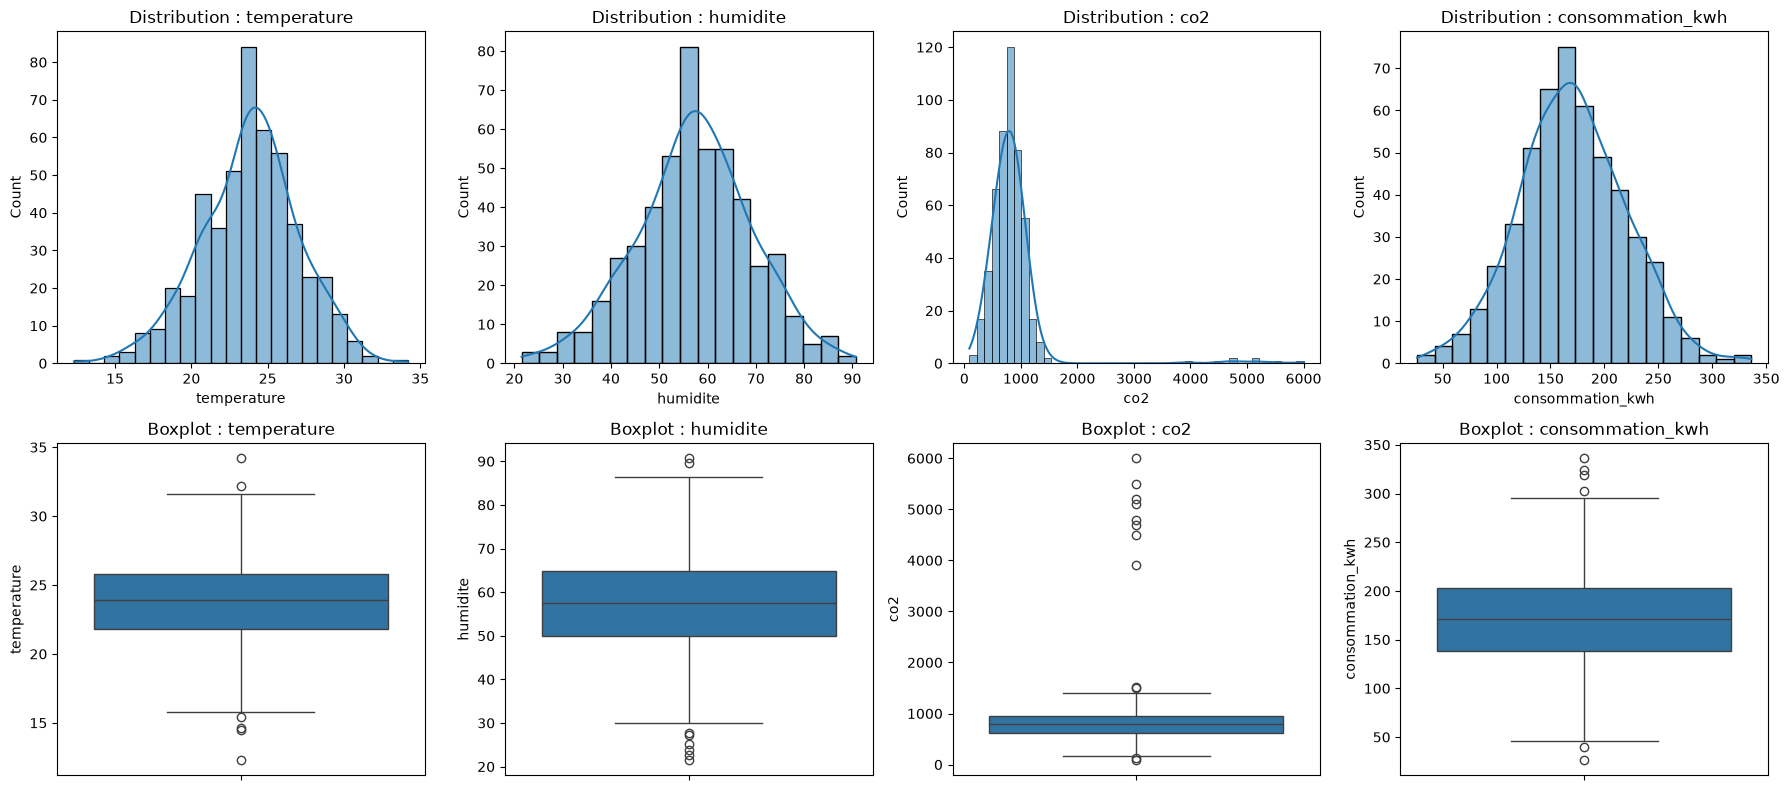

In [96]:

colonnes = ['temperature', 'humidite', 'co2', 'consommation_kwh']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(colonnes):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'Distribution : {col}')
    
    sns.boxplot(y=df[col], ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot : {col}')

plt.tight_layout()
plt.show()

la temperature et l'humidite sont plutôt symétriques (en forme de cloche), tandis que co2 et consommation_kwh peuvent présenter une légère asymétrie à droite (quelques valeurs très hautes qui tirent la queue de la distribution).

b) La dispersion

In [97]:
df.describe()

,id_mesure,date,temperature,humidite,co2,occupation,consommation_kwh
count,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,2025-03-04 09:45:30.033466,23.843775,57.279200,844.817000,45.216738,170.590978
min,1001.000000,2025-01-01 00:00:00,12.300000,21.500000,89.000000,0.000000,26.400000
25%,1125.750000,2025-02-01 10:30:00,21.775000,50.000000,627.750000,28.000000,137.825000
50%,1250.500000,2025-03-04 13:26:03.346613,23.900000,57.400000,787.500000,45.397177,170.798795
75%,1375.250000,2025-04-04 07:30:00,25.800000,64.900000,950.500000,60.000000,202.725000
max,1500.000000,2025-05-05 18:00:00,34.200000,90.700000,6000.000000,116.000000,336.200000
std,144.481833,NaN,3.207096,12.001583,581.432617,24.195937,49.376702


visible avec l'écart-type de describe() et la largeur des boxplots : consommation_kwh a une dispersion plus large que humidite

c) Les valeurs extrêmes

les points isolés au-dessus/en-dessous des "moustaches" du boxplot.

d) les valeurs potentiellement aberrantes

In [98]:
def detecter_aberrantes(colonne):
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    aberrantes = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]
    return aberrantes

for col in colonnes:
    aberrantes = detecter_aberrantes(col)
    print(f"{col} : {len(aberrantes)} valeurs aberrantes (bornes IQR)")

temperature : 6 valeurs aberrantes (bornes IQR)
humidite : 8 valeurs aberrantes (bornes IQR)
co2 : 12 valeurs aberrantes (bornes IQR)
consommation_kwh : 6 valeurs aberrantes (bornes IQR)


16) Quelle stratégie utiliser pour les valeurs aberrantes ?

Les remplacer par la valeur maximale/minimale acceptable (au lieu de les supprimer)

In [99]:
Q1 = df['co2'].quantile(0.25)
Q3 = df['co2'].quantile(0.75)
IQR = Q3 - Q1
limite_haute = Q3 + 1.5 * IQR

print(limite_haute)
print(df[df['co2'] > limite_haute])

1434.625
     id_mesure                date batiment      type_batiment zone  \
28        1211 2025-02-22 12:00:00       b6         université    d   
44        1091 2025-01-23 12:00:00       b5  centre commercial    b   
241       1151 2025-02-07 12:00:00       b6         université    d   
295       1371 2025-04-03 12:00:00       b1             bureau    c   
299       1311 2025-03-19 12:00:00       b3            hôpital    a   
328       1284 2025-03-12 18:00:00       b4             bureau    d   
433       1431 2025-04-18 12:00:00       b2              école    c   
459       1051 2025-01-13 12:00:00       b7             bureau    d   
487       1131 2025-02-02 12:00:00       b1           entrepôt    a   
503       1271 2025-03-09 12:00:00       b3            hôpital    b   

     temperature  humidite     co2  occupation  consommation_kwh  \
28          16.6      42.3  6000.0   40.000000              82.5   
44          28.3      72.8  5200.0   44.000000             171.5   
241  

17) Afficher la fréquence des :

 bâtiments, types de bâtiments, modes de climatisation, états du système, classes alerte

In [100]:
print(df['batiment'].value_counts())
print(df['type_batiment'].value_counts())
print(df['mode_climatisation'].value_counts())
print(df['etat_systeme'].value_counts())
print(df['alerte'].value_counts())

batiment
b1    92
b5    65
b7    64
b2    60
b4    58
b3    57
b8    53
b6    51
Name: count, dtype: int64
type_batiment
bureau               211
centre commercial     65
école                 59
hôpital               58
entrepôt              53
université            49
ecole                  1
Name: count, dtype: int64
mode_climatisation
normal    268
eco       130
boost      97
Name: count, dtype: int64
etat_systeme
normal    436
alerte     52
panne      12
Name: count, dtype: int64
alerte
non    356
oui    144
Name: count, dtype: int64


18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

In [101]:
print(df['alerte'].value_counts(normalize=True) * 100)

alerte
non    71.2
oui    28.8
Name: proportion, dtype: float64


Environ 71% "Non" contre 29% "Oui" : c'est un déséquilibre modéré

19) Pour la corrélation sur les variables numériques :

a) visualiser avec seaborn, la matrice de corrélation.

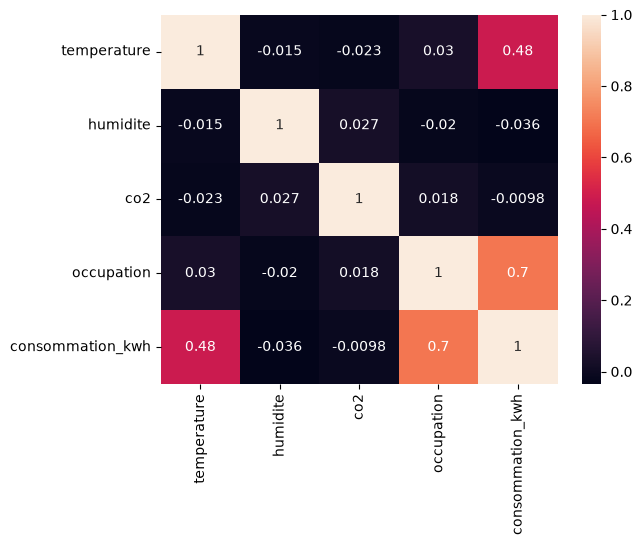

In [102]:
colonnes_num = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
matrice = df[colonnes_num].corr()

sns.heatmap(matrice, annot=True)
plt.show()

b) identifier les corrélations positives, négatives et les variables faiblement corrélées.

In [103]:
print(matrice)

                  temperature  humidite       co2  occupation  \
temperature          1.000000 -0.014734 -0.022504    0.030461   
humidite            -0.014734  1.000000  0.027159   -0.019952   
co2                 -0.022504  0.027159  1.000000    0.017617   
occupation           0.030461 -0.019952  0.017617    1.000000   
consommation_kwh     0.482249 -0.035637 -0.009794    0.704487   

                  consommation_kwh  
temperature               0.482249  
humidite                 -0.035637  
co2                      -0.009794  
occupation                0.704487  
consommation_kwh          1.000000  


# Partie 2 – Séparation X / y

1) Définir la variable "alerte" comme la cible y

In [104]:
y = df['alerte']

2) Trouver des variables explicatives X pertinentes

In [105]:
X = df.drop('alerte', axis=1)
X = X.drop('id_mesure', axis=1)
X = X.drop('date', axis=1)

3) Afficher les cinq premières lignes de X ainsi que de y

In [106]:
print(X.head())
print(y.head())

  batiment      type_batiment zone  temperature  humidite     co2  occupation  \
0       b8           entrepôt    a         23.0      40.0   851.0        26.0   
1       b7             bureau    d         28.0      69.0   538.0         0.0   
2       b5  centre commercial    b         19.5      52.3  1198.0        64.0   
3       b6         université    d         20.0      58.4  1014.0        30.0   
4       b7             bureau    d         26.8      70.5   628.0        42.0   

   consommation_kwh mode_climatisation etat_systeme jour_semaine  
0             138.4                eco       normal        jeudi  
1             170.2                eco       normal        lundi  
2             149.8             normal       normal     dimanche  
3             141.6             normal       normal     dimanche  
4             228.3             normal       normal        jeudi  
0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: str


# Partie 3 – Découpage Train/Test

Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test).
Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du
découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que
dans les données d'origine.

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(400, 11)
(100, 11)


# Partie 4 – Encodage des variables catégorielles

Appliquer, en justifiant, l’encodage le plus adapté à chaque variable catégorielle

Colonnes sans ordre logique (batiment, type_batiment, zone, etat_systeme, jour_semaine) → on utilise le one-hot encoding, très simple avec pd.get_dummies pour éviter la création d'un ordre:

In [108]:
X_train = pd.get_dummies(X_train, columns=['batiment', 'type_batiment', 'zone', 'etat_systeme', 'jour_semaine'])
X_test = pd.get_dummies(X_test, columns=['batiment', 'type_batiment', 'zone', 'etat_systeme', 'jour_semaine'])

Colonne avec un ordre logique (mode_climatisation : eco < normal < boost) → on remplace chaque catégorie par un nombre :

In [109]:
ordre = {'eco': 0, 'normal': 1, 'boost': 2}

X_train['mode_climatisation'] = X_train['mode_climatisation'].map(ordre)
X_test['mode_climatisation'] = X_test['mode_climatisation'].map(ordre)

print(X_train.head())

     temperature  humidite    co2  occupation  consommation_kwh  \
265         23.1      62.2  952.0        16.0             134.6   
110         23.5      59.2  807.0        48.0             142.0   
149         26.2      51.1  274.0        69.0             247.7   
5           24.2      51.5  624.0        52.0             171.9   
66          20.4      53.2  710.0         7.0              84.9   

     mode_climatisation  batiment_b1  batiment_b2  batiment_b3  batiment_b4  \
265                 1.0        False        False        False        False   
110                 NaN        False         True        False        False   
149                 2.0         True        False        False        False   
5                   0.0        False        False         True        False   
66                  1.0        False        False        False        False   

     ...  etat_systeme_alerte  etat_systeme_normal  etat_systeme_panne  \
265  ...                False                 Tr

# Partie 5 – Mise à l'échelle

1) A l’aide de quelques variables, justifier la pertinence de la mise à l’échelle

In [110]:
print(X_train[['temperature', 'humidite', 'co2', 'consommation_kwh']].describe())

       temperature   humidite          co2  consommation_kwh
count   400.000000  400.00000   400.000000        400.000000
mean     23.802032   57.02375   837.405000        170.475476
std       3.233404   11.85138   553.925076         50.705520
min      12.300000   21.50000    89.000000         26.400000
25%      21.800000   50.30000   630.250000        136.550000
50%      23.843763   57.40000   786.750000        169.950000
75%      25.800000   64.45000   949.750000        204.550000
max      34.200000   89.50000  6000.000000        336.200000


Pourquoi c'est utile: co2 va jusqu'à plusieurs milliers alors que humidite reste entre 0 et 100. Sans mise à l'échelle, co2 compterait beaucoup plus que les autres variables pour le modèle, juste à cause de son échelle.

2) Appliquer et justifier une technique de mise à l'échelle

In [111]:
from sklearn.preprocessing import StandardScaler

colonnes_a_normaliser = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']

scaler = StandardScaler()
scaler.fit(X_train[colonnes_a_normaliser])

X_train[colonnes_a_normaliser] = scaler.transform(X_train[colonnes_a_normaliser])
X_test[colonnes_a_normaliser] = scaler.transform(X_test[colonnes_a_normaliser])

print(X_train[colonnes_a_normaliser].describe())

        temperature      humidite           co2    occupation  \
count  4.000000e+02  4.000000e+02  4.000000e+02  4.000000e+02   
mean   3.730349e-16  3.330669e-17  5.329071e-17 -3.108624e-16   
std    1.001252e+00  1.001252e+00  1.001252e+00  1.001252e+00   
min   -3.561707e+00 -3.001190e+00 -1.352786e+00 -1.861603e+00   
25%   -6.199470e-01 -5.680495e-01 -3.744449e-01 -7.267023e-01   
50%    1.292240e-02  3.178712e-02 -9.156191e-02 -4.979622e-03   
75%    6.186887e-01  6.273996e-01  2.030702e-01  6.024613e-01   
max    3.219824e+00  2.743725e+00  9.331696e+00  2.882488e+00   

       consommation_kwh  
count      4.000000e+02  
mean       3.996803e-16  
std        1.001252e+00  
min       -2.844974e+00  
25%       -6.699066e-01  
50%       -1.037627e-02  
75%        6.728498e-01  
max        3.272466e+00  


On choisit le StandardScaler car nos variables ont des distributions à peu près symétriques

3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?

Si on calcule la moyenne/écart-type sur train + test ensemble, le modèle "voit" indirectement des informations du test avant l'évaluation. C'est la fuite de données. Il faut toujours faire fit sur le train seulement, puis transform sur train et test.

# Partie 6 – Pipeline de preprocessing

In [112]:
# Étape 1 : recharger les données propres
df2 = df.copy()

# Étape 2 : séparer X et y
y = df2['alerte']
X = df2.drop('alerte', axis=1)
X = X.drop('id_mesure', axis=1)
X = X.drop('date', axis=1)

# Étape 3 : train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Étape 4 : imputation des variables numériques (médiane)
colonnes_num = ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']

for col in colonnes_num:
    mediane = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediane)
    X_test[col] = X_test[col].fillna(mediane)

# Étape 5 : imputation des variables catégorielles (mode)
colonnes_cat = ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine']

for col in colonnes_cat:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

# Étape 6 : StandardScaler sur les variables numériques
scaler = StandardScaler()
scaler.fit(X_train[colonnes_num])
X_train[colonnes_num] = scaler.transform(X_train[colonnes_num])
X_test[colonnes_num] = scaler.transform(X_test[colonnes_num])

# Étape 7 : OneHotEncoder sur les catégorielles sans ordre
colonnes_onehot = ['batiment', 'type_batiment', 'zone', 'etat_systeme', 'jour_semaine']
X_train = pd.get_dummies(X_train, columns=colonnes_onehot)
X_test = pd.get_dummies(X_test, columns=colonnes_onehot)

# Étape 8 : encodage ordinal pour mode_climatisation
ordre = {'eco': 0, 'normal': 1, 'boost': 2}
X_train['mode_climatisation'] = X_train['mode_climatisation'].map(ordre)
X_test['mode_climatisation'] = X_test['mode_climatisation'].map(ordre)

print(X_train.head())

     temperature  humidite       co2  occupation  consommation_kwh  \
265    -0.217390  0.437310  0.207137   -1.207246         -0.708412   
110    -0.093527  0.183858 -0.054959    0.101469         -0.562289   
149     0.742552 -0.500462 -1.018388    0.960313          1.524908   
5       0.123234 -0.466669 -0.385742    0.265058          0.028129   
66     -1.053469 -0.323046 -0.230292   -1.575322         -1.689809   

     mode_climatisation  batiment_b1  batiment_b2  batiment_b3  batiment_b4  \
265                   1        False        False        False        False   
110                   1        False         True        False        False   
149                   2         True        False        False        False   
5                     0        False        False         True        False   
66                    1        False        False        False        False   

     ...  etat_systeme_alerte  etat_systeme_normal  etat_systeme_panne  \
265  ...                False 

# Partie 7 : Exportation

In [116]:
df_final = df.copy()
df_final.to_csv('../exports/smart_building_cleaned.csv', index=False)
print("Export terminé")

Export terminé
